In [1]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

# Classification models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\git tutorial\project-1-MLOP\notebook\train.csv")

In [3]:
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


0 = Not addicted
1 = Addicted

In [4]:
df.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
null_percent = (df.isnull().sum() / len(df)) * 100
print(null_percent)

id                          0.000000
age                         4.184307
daily_screen_time_hours    13.864376
social_media_hours         19.381112
gaming_hours               18.343461
work_study_hours            7.451592
sleep_hours                 6.433612
notifications_per_day       9.775388
app_opens_per_day          11.673940
weekend_screen_time        16.208855
gender                      4.199494
stress_level                7.976638
academic_work_impact        6.396584
addicted_label              0.000000
dtype: float64


In [7]:
df.shape

(691369, 14)

In [8]:
num_cols = df.select_dtypes(include="number").columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [9]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
df.isnull().sum()

id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
addicted_label             0
dtype: int64

In [11]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='str')

In [12]:
df.drop(columns=["id"], inplace=True)

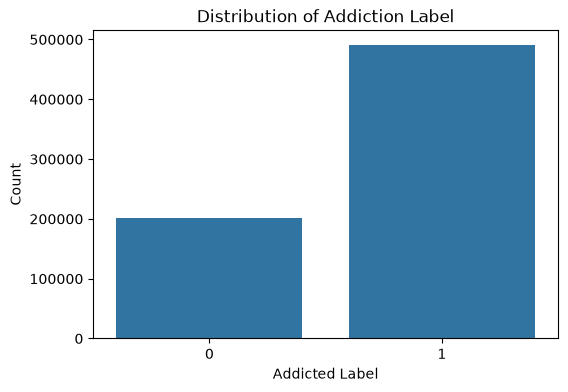

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="addicted_label")

plt.title("Distribution of Addiction Label")
plt.xlabel("Addicted Label")
plt.ylabel("Count")
plt.show()

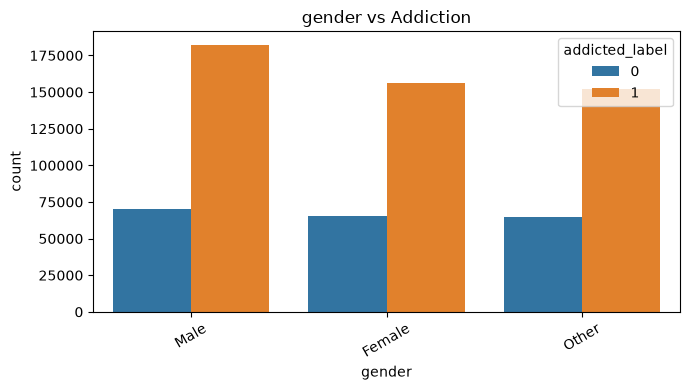

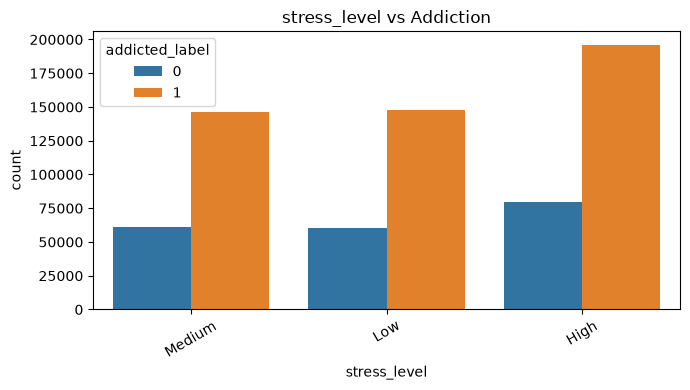

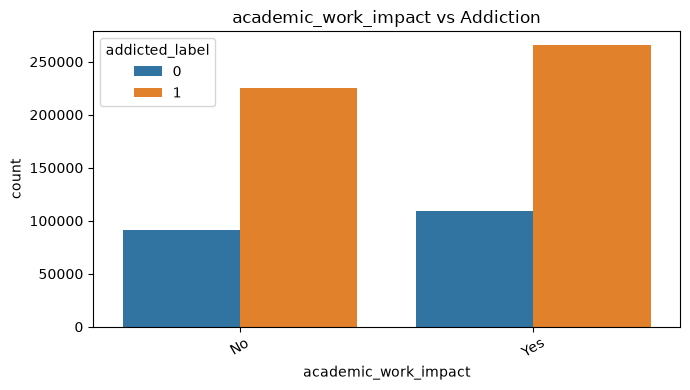

In [14]:
categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue="addicted_label")
    plt.title(f"{col} vs Addiction")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

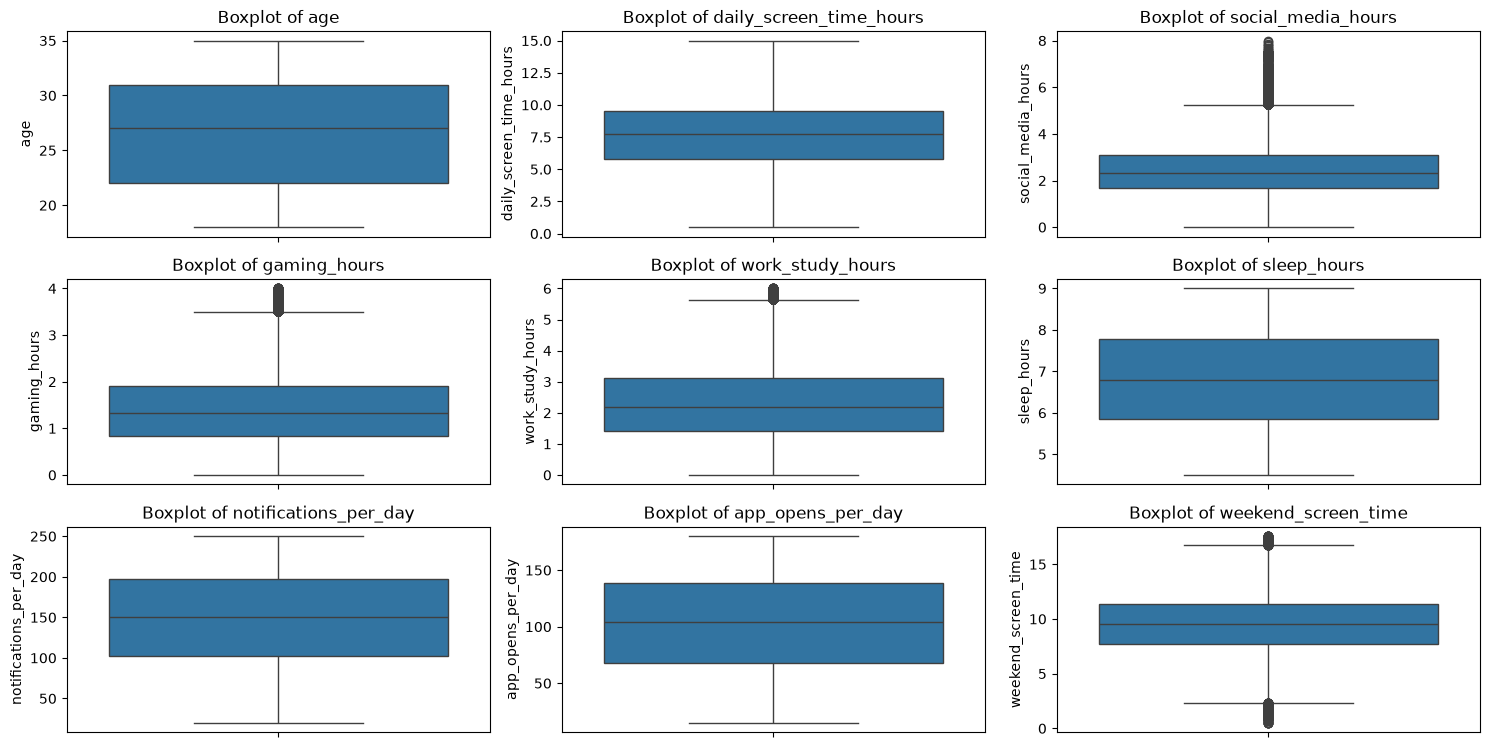

In [15]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Remove target variable
numeric_cols.remove("addicted_label")

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

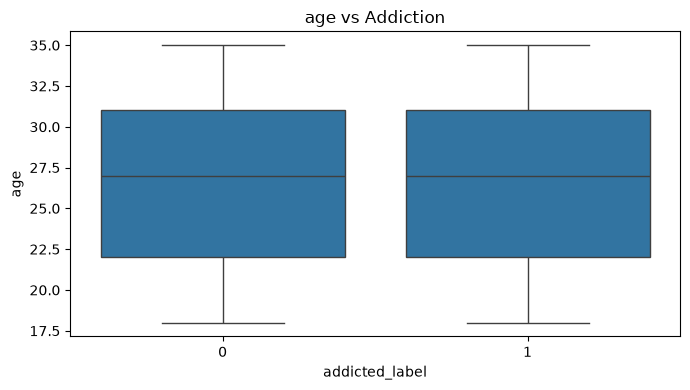

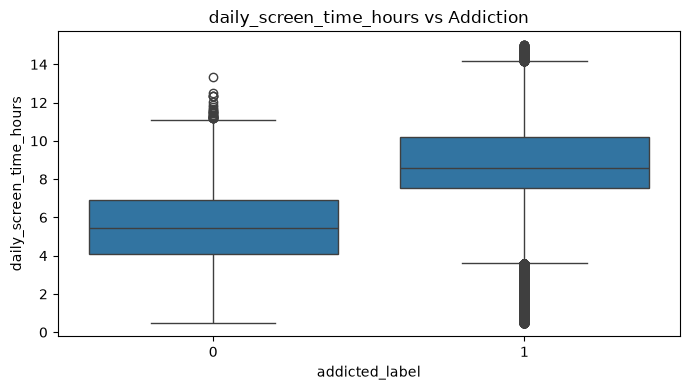

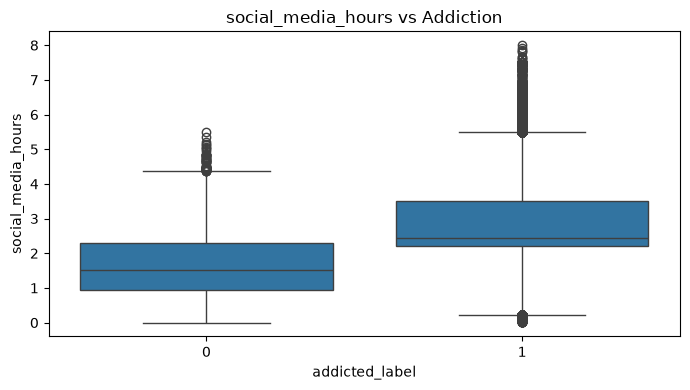

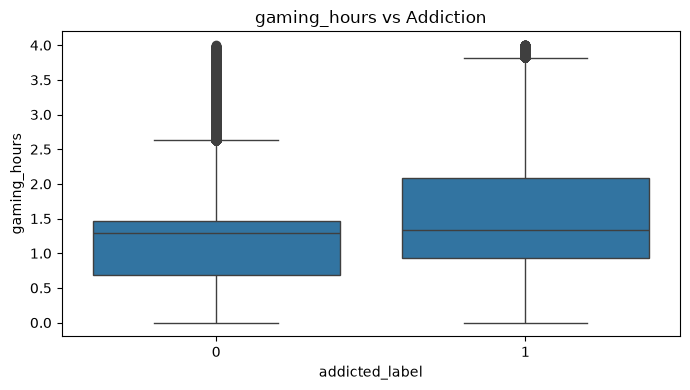

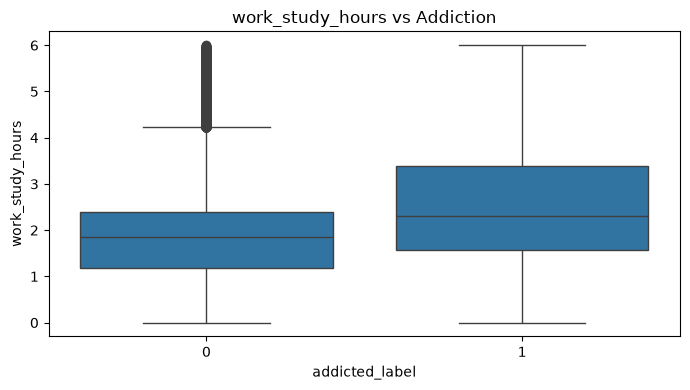

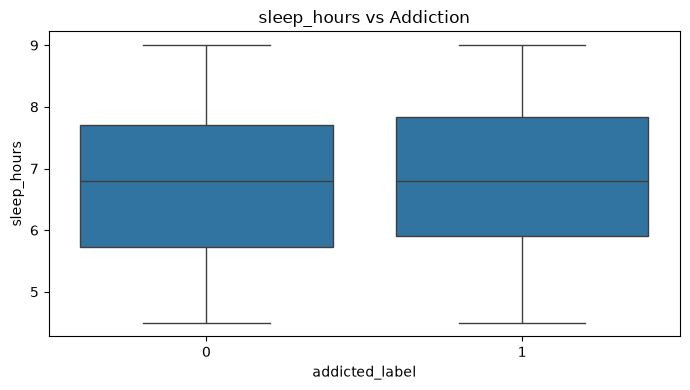

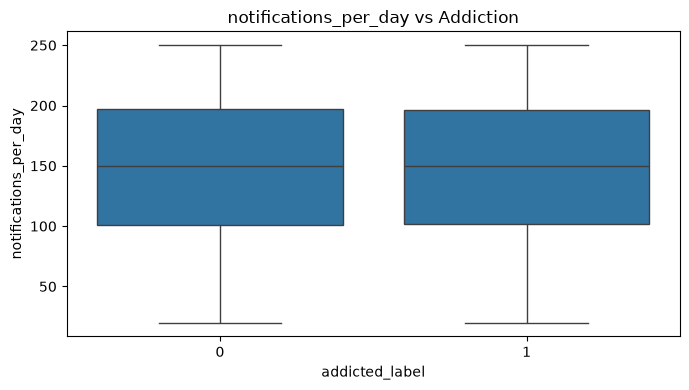

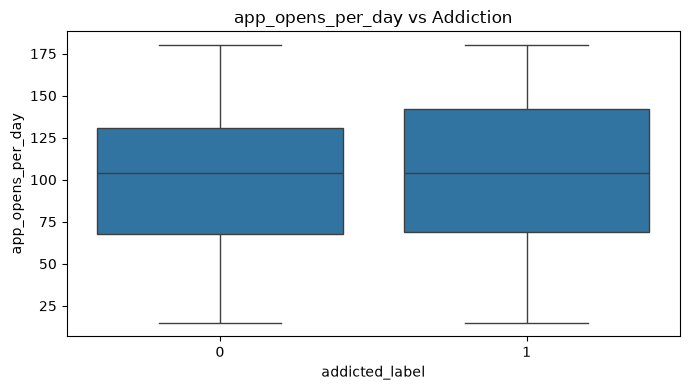

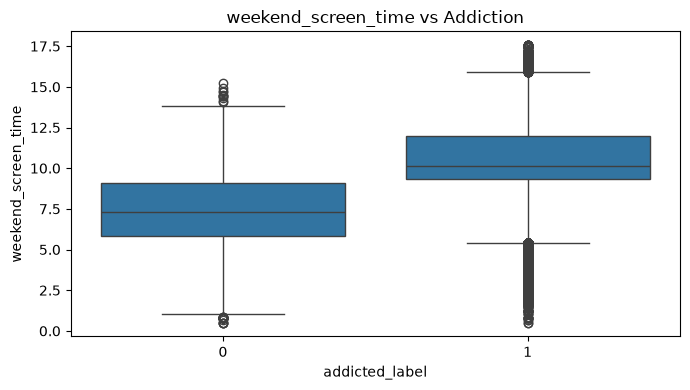

In [16]:
numeric_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="addicted_label", y=col)
    plt.title(f"{col} vs Addiction")
    plt.tight_layout()
    plt.show()

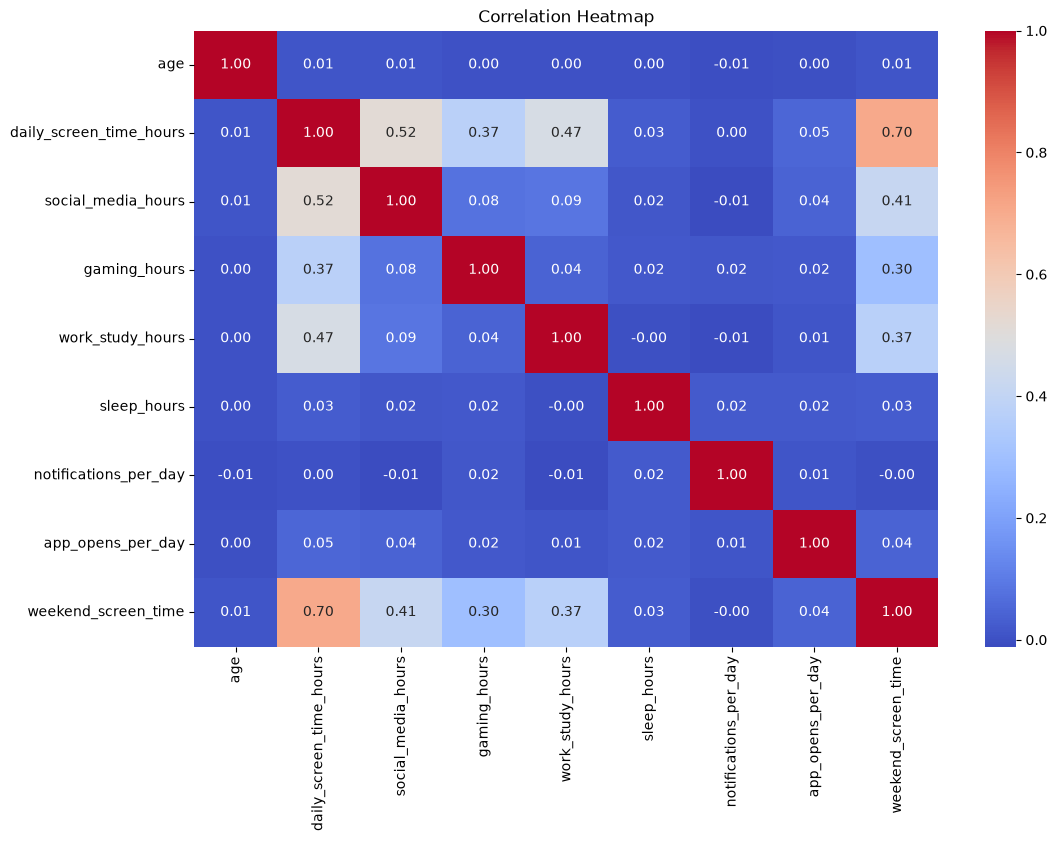

In [17]:
plt.figure(figsize=(12, 8))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

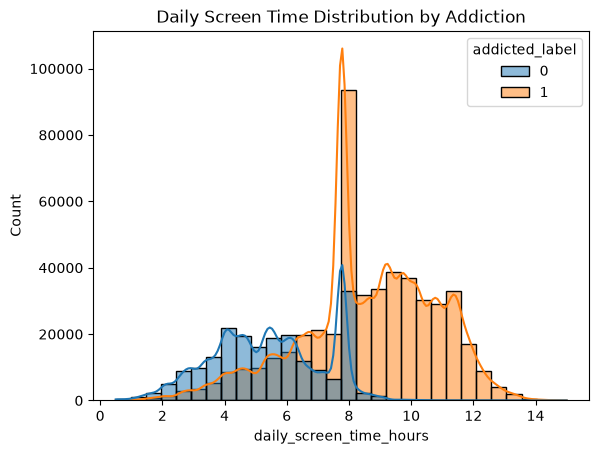

In [18]:
sns.histplot(
    data=df,
    x="daily_screen_time_hours",
    hue="addicted_label",
    kde=True,
    bins=30
)

plt.title("Daily Screen Time Distribution by Addiction")
plt.show()

In [19]:
##feature engineering
df["recreational_screen_time"] = (
    df["social_media_hours"] +
    df["gaming_hours"]
)

In [20]:
df["other_screen_time"] = (
    df["daily_screen_time_hours"]
    - df["social_media_hours"]
    - df["gaming_hours"]
)

In [21]:
df["weekend_screen_difference"] = (
    df["weekend_screen_time"]
    - df["daily_screen_time_hours"]
)

In [22]:
df["weekend_screen_ratio"] = (
    df["weekend_screen_time"] /
    (df["daily_screen_time_hours"] + 1e-6)
)

In [23]:
df["screen_sleep_ratio"] = (
    df["daily_screen_time_hours"] /
    (df["sleep_hours"] + 1e-6)
)

In [24]:
df["social_media_ratio"] = (
    df["social_media_hours"] /
    (df["daily_screen_time_hours"] + 1e-6)
)

In [25]:
df["gaming_ratio"] = (
    df["gaming_hours"] /
    (df["daily_screen_time_hours"] + 1e-6)
)

In [26]:
df["app_opens_per_screen_hour"] = (
    df["app_opens_per_day"] /
    (df["daily_screen_time_hours"] + 1e-6)
)

In [27]:
df["notifications_per_screen_hour"] = (
    df["notifications_per_day"] /
    (df["daily_screen_time_hours"] + 1e-6)
)

In [28]:
df["screen_to_work_ratio"] = (
    df["daily_screen_time_hours"] /
    (df["work_study_hours"] + 1e-6)
)

In [29]:
df["total_tracked_hours"] = (
    df["daily_screen_time_hours"] +
    df["sleep_hours"] +
    df["work_study_hours"]
)

In [30]:
df["free_time_hours"] = (
    24 - df["sleep_hours"] - df["work_study_hours"]
)

In [31]:
df["screen_time_category"] = pd.cut(
    df["daily_screen_time_hours"],
    bins=[-float("inf"), 4, 8, float("inf")],
    labels=["Low", "Moderate", "High"]
)

In [32]:
df["sleep_category"] = pd.cut(
    df["sleep_hours"],
    bins=[-float("inf"), 6, 8, float("inf")],
    labels=["Low Sleep", "Normal Sleep", "High Sleep"]
)

In [33]:
df["high_screen_time"] = (
    df["daily_screen_time_hours"] >= 8
).astype(int)

In [34]:
df["high_social_media_usage"] = (
    df["social_media_hours"] >= 4
).astype(int)

df["high_gaming_usage"] = (
    df["gaming_hours"] >= 4
).astype(int)

In [35]:
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,...,app_opens_per_screen_hour,notifications_per_screen_hour,screen_to_work_ratio,total_tracked_hours,free_time_hours,screen_time_category,sleep_category,high_screen_time,high_social_media_usage,high_gaming_usage
0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,...,4.890604,15.701414,3.682463,17.34,14.43,Moderate,Normal Sleep,0,0,0
1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,Female,...,3.182579,12.730316,1.970296,17.22,12.75,Moderate,High Sleep,0,0,0
2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,Female,...,11.787817,26.326124,2.313635,13.54,15.55,Moderate,Normal Sleep,0,0,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,...,14.641742,17.445480,1.910714,18.63,11.79,Moderate,High Sleep,0,0,0
4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,Female,...,9.285713,13.392856,5.743587,18.40,16.80,High,Low Sleep,1,0,0


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   age                            691369 non-null  float64 
 1   daily_screen_time_hours        691369 non-null  float64 
 2   social_media_hours             691369 non-null  float64 
 3   gaming_hours                   691369 non-null  float64 
 4   work_study_hours               691369 non-null  float64 
 5   sleep_hours                    691369 non-null  float64 
 6   notifications_per_day          691369 non-null  float64 
 7   app_opens_per_day              691369 non-null  float64 
 8   weekend_screen_time            691369 non-null  float64 
 9   gender                         691369 non-null  str     
 10  stress_level                   691369 non-null  str     
 11  academic_work_impact           691369 non-null  str     
 12  addicted_label             

In [37]:
categorical_cols = df.select_dtypes(
    include=["object","category","string"]
).columns.to_list()

print(categorical_cols)

['gender', 'stress_level', 'academic_work_impact', 'screen_time_category', 'sleep_category']


In [38]:
categorical_cols

['gender',
 'stress_level',
 'academic_work_impact',
 'screen_time_category',
 'sleep_category']

In [39]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [40]:
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,...,app_opens_per_screen_hour,notifications_per_screen_hour,screen_to_work_ratio,total_tracked_hours,free_time_hours,screen_time_category,sleep_category,high_screen_time,high_social_media_usage,high_gaming_usage
0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1,...,4.890604,15.701414,3.682463,17.34,14.43,2,2,0,0,0
1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,0,...,3.182579,12.730316,1.970296,17.22,12.75,2,0,0,0,0
2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,0,...,11.787817,26.326124,2.313635,13.54,15.55,2,2,0,0,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,...,14.641742,17.445480,1.910714,18.63,11.79,2,0,0,0,0
4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,0,...,9.285713,13.392856,5.743587,18.40,16.80,0,1,1,0,0


In [41]:
X = df.drop(columns="addicted_label")
y = df["addicted_label"]

In [42]:
from imblearn.over_sampling import RandomOverSampler

# Initialize the sampler
ros = RandomOverSampler(random_state=42)

# Resample the dataset
X, y = ros.fit_resample(X, y)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_lr, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_lr, zero_division=0))

Logistic Regression
Accuracy : 0.8420612671389979
Precision: 0.868815880587828
Recall   : 0.805790305316275
F1 Score : 0.8361170758538985


In [45]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_dt, zero_division=0))

Decision Tree
Accuracy : 0.9209949538712473
Precision: 0.9783401864828865
Recall   : 0.8610530608084
F1 Score : 0.9159572737624031


In [46]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_rf, zero_division=0))

Random Forest
Accuracy : 0.9307915795912126
Precision: 0.9870679222231187
Recall   : 0.8730210510219685
F1 Score : 0.9265482321374475


In [47]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_gb, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_gb, zero_division=0))

Gradient Boosting
Accuracy : 0.8596513583770834
Precision: 0.8976734749086974
Recall   : 0.8118456598195627
F1 Score : 0.8526050393178132


In [48]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_knn, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_knn, zero_division=0))

KNN
Accuracy : 0.8508588613079158
Precision: 0.9036911925120518
Recall   : 0.7854222947143076
F1 Score : 0.8404162485274227


In [49]:
from sklearn.ensemble import StackingClassifier
# Base models
estimators = [
    ("rf", RandomForestClassifier()),
    ("dt", DecisionTreeClassifier())
]

# Stacking model
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Train
stack_model.fit(X_train, y_train)

# Prediction
y_pred = stack_model.predict(X_test)

In [51]:
accuracy_score(y_test,y_pred)

0.9504103165298945